# Bayesian Deep Learning

Bayesian Deep Learning is a field that tries to quantify uncertainty in artificial neural networks. In this approach, the weights of a model are treated as distributions instead of fixed values.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch.nn import GaussianNLLLoss
from torch.optim import Adam

from pai import BNNLA, BNNVI, BNNMCMC, BNNDropout
from scoring import bnn_loss, negative_elbo, sgdl_loss

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_numpy = np.linspace(-6 * np.pi, 6 * np.pi, 1000).reshape((1000, 1))
x_short = np.concatenate([x_numpy[:20], x_numpy[40:80], x_numpy[100:120], x_numpy[150:]])
y_numpy = np.sin(0.2 * x_short) + rng.normal(0, 0.2, size=x_short.shape)

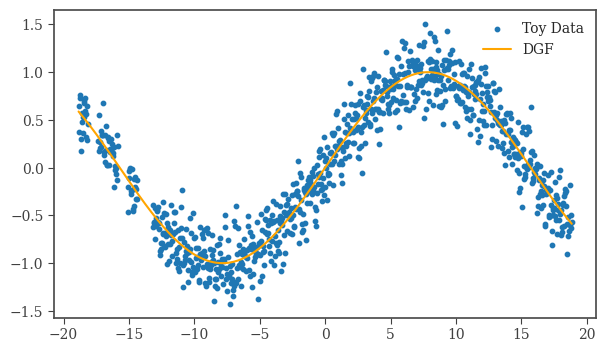

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y_numpy, label="Toy Data", s=10)
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.legend()

plt.show()

## BNN with Laplace Approximation

A common problem with such Bayesian methods are intractable computations due to high computation costs. As such, it is common to use approximations. One possible approach are neural networks with Laplace Approximations, where the true posterior is approximated using a Gaussian distribution.

In [4]:
x = torch.from_numpy(x_short).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

In [5]:
inv_prior = 0.009

bnn = BNNLA(x.shape[1], inv_prior)
optimizer = Adam(bnn.parameters(), lr=0.01, weight_decay=inv_prior)

for epoch in range(2_000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn(x)
    loss = bnn_loss(y_mean, y_log_var, y)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 0.4646
E100: Loss -1.0811
E200: Loss -1.1062
E300: Loss -1.1047
E400: Loss -1.1280
E500: Loss -1.1342
E600: Loss -1.1298
E700: Loss -1.1352
E800: Loss -1.1319
E900: Loss -1.1339
E1000: Loss -1.1292
E1100: Loss -1.0923
E1200: Loss -1.1329
E1300: Loss -1.1170
E1400: Loss -1.1354
E1500: Loss -1.1233
E1600: Loss -1.1347
E1700: Loss -1.1357
E1800: Loss -1.1354
E1900: Loss -1.1350


In [6]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

bnn.covariance(x_long)
y_pred, var_pred, total_var_pred = bnn.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

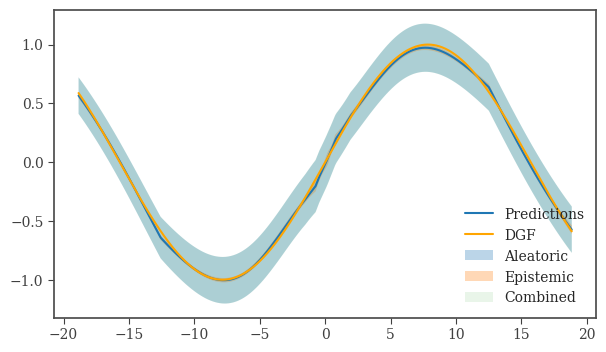

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, label="Aleatoric", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - epistemic_std, y_pred + epistemic_std, label="Epistemic", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, label="Combined", alpha=0.1)

ax.legend()

plt.show()

## Bayesian Neural Network with Variational Inference

A Bayesian Neural Network treats parameters as distributions instead of weights. The implementation used here stores the mean and variance of a normal distribution for each weight. Since full computation of the posterior is impossible, the implementation furthermore uses variational inference, where the posterior is approximated using a simpler distribution. Furthermore, since this relies on differentiating with respect to the parameters we sample from, the reparametrization trick is used.

In [8]:
bnn_vi = BNNVI(x.shape[1])
optimizer = Adam(bnn_vi.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn_vi(x)

    loss = negative_elbo(y_mean, y_log_var, y, bnn_vi.kl_divergence())
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 3.3281
E100: Loss 2.6874
E200: Loss 2.6869
E300: Loss 2.5322
E400: Loss 2.5318
E500: Loss 2.4536
E600: Loss 2.5328
E700: Loss 2.3740
E800: Loss 2.4948
E900: Loss 2.4023


In the inference step, several weights are sample using Monte Carlo sampling. From these samples, the mean, epistemic and aleatoric variances are predicted.

In [9]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_vi.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

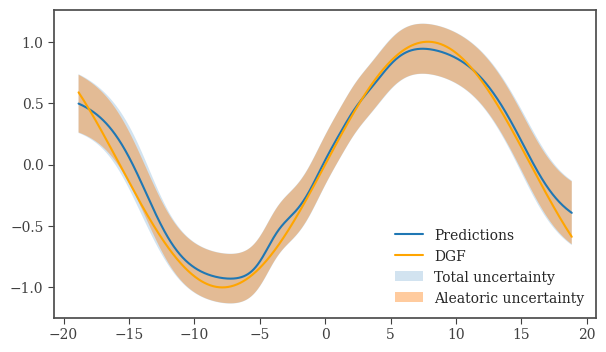

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty", )

ax.legend()

plt.show()

## MCMC for Neural Networks

There also exist MCMC methods for Bayesian Neural Networks. They work by saving weight samples every few training steps and averaging over model predictions of each stored weight sample to provide an estimate of the mean prediction. At the same time, this approach also gives an estimate of the epistemic uncertainty. The model used below is configured to predict the aleatoric uncertainty, too.

During training, random Gaussian noise is added. This is called Stochastic Gradient Langevin Dynamics.

In [11]:
num_samples, num_features = x.shape[0], x.shape[1]
random_permutation = torch.randperm(num_samples)

x = x[random_permutation]
y = y[random_permutation]

prior_variance = 1.0
bnn_mcmc = BNNMCMC(in_features=num_features, prior_variance=prior_variance)

batch_size = 64
steps = num_samples // batch_size
step_size = 2e-5
epochs = 500
burn_in_epochs = 450

for epoch in range(epochs):
    epoch_loss = 0
    for step in range(steps):
        x_batch = x[(step * batch_size):((step + 1) * batch_size)]
        y_batch = y[(step * batch_size):((step + 1) * batch_size)]
        bnn_mcmc.zero_grad()

        y_mean, y_log_var = bnn_mcmc(x_batch)

        nl_prior = bnn_mcmc.negative_log_prior()
        loss = sgdl_loss(y_mean, y_log_var, y_batch, nl_prior, num_samples)

        loss.backward()
        with torch.no_grad():
            for parameter in bnn_mcmc.parameters():
                noise = torch.randn_like(parameter)

                parameter.add_(
                    -0.5 * step_size * parameter.grad + step_size ** 0.5 * noise
                )
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"E{epoch}: Loss {epoch_loss / steps}")

    if epoch > burn_in_epochs:
        bnn_mcmc.store_weight_sample()

E0: Loss 280.475961957659
E10: Loss -67.95444434029716
E20: Loss -180.18529564993722
E30: Loss -189.87361907958984
E40: Loss -188.9344940185547
E50: Loss -192.42959104265486
E60: Loss -196.3009033203125
E70: Loss -207.32476425170898
E80: Loss -219.5053825378418
E90: Loss -225.9790382385254
E100: Loss -224.4256831577846
E110: Loss -242.31031690325057
E120: Loss -251.4717069353376
E130: Loss -271.80228424072266
E140: Loss -284.0862928118025
E150: Loss -306.8036629813058
E160: Loss -333.08599853515625
E170: Loss -367.17993600027904
E180: Loss -407.5032719203404
E190: Loss -444.5569370814732
E200: Loss -478.8195473807199
E210: Loss -498.3610098702567
E220: Loss -532.3182373046875
E230: Loss -548.518072945731
E240: Loss -573.7069920131138
E250: Loss -613.2491171700614
E260: Loss -634.8978358677456
E270: Loss -628.295654296875
E280: Loss -622.7820434570312
E290: Loss -643.6979326520648
E300: Loss -660.2464338030134
E310: Loss -631.9698486328125
E320: Loss -652.2693721226284
E330: Loss -622.7

In [12]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_mcmc.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

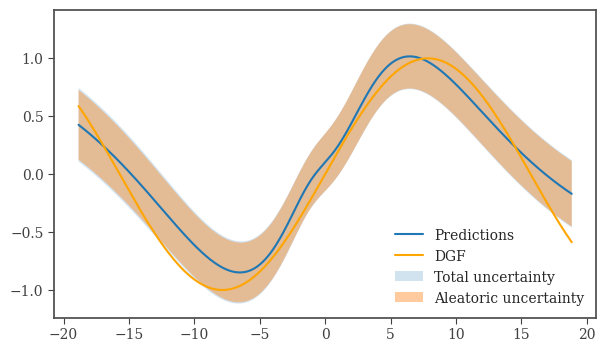

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty")

ax.legend()

plt.show()

## BNN with Dropout as Variational Inference

Using dropout during inference can be seen as a way of performing variational inference. The input is sent through the model multiple times with inference kept on, and these estimates are used to approximate the epistemic uncertainty and mean prediction. The model is configured to predict the aleatoric uncertainty, too.

In [61]:
num_samples, num_features = x.shape[0], x.shape[1]
random_permutation = torch.randperm(num_samples)

x = x[random_permutation]
y = y[random_permutation]

bnn_dropout = BNNDropout(in_features=num_features)
optimizer = Adam(bnn_dropout.parameters(), lr=0.002)
nll_loss = GaussianNLLLoss()

batch_size = 64
steps = num_samples // batch_size
step_size = 2e-5
epochs = 500

for epoch in range(epochs):
    epoch_loss = 0
    for step in range(steps):
        x_batch = x[(step * batch_size):((step + 1) * batch_size)]
        y_batch = y[(step * batch_size):((step + 1) * batch_size)]
        optimizer.zero_grad()

        y_mean, y_log_var = bnn_dropout(x_batch)
        y_var = y_log_var.exp()

        loss = nll_loss(y_mean, y_batch, y_var)
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"E{epoch}: Loss {epoch_loss / steps}")

E0: Loss 1.2178968233721597
E10: Loss 0.024293905323637382
E20: Loss -0.19012866861053876
E30: Loss -0.28758070511477335
E40: Loss -0.3238972936357771
E50: Loss -0.33997185102530886
E60: Loss -0.3615006644810949
E70: Loss -0.4020317292639187
E80: Loss -0.4381367415189743
E90: Loss -0.44724022277763914
E100: Loss -0.4530837173972811
E110: Loss -0.46875169447490145
E120: Loss -0.4773391953536442
E130: Loss -0.4866644697529929
E140: Loss -0.4982401877641678
E150: Loss -0.5256301867110389
E160: Loss -0.5212923245770591
E170: Loss -0.5301848713840757
E180: Loss -0.5374023786612919
E190: Loss -0.5109201541968754
E200: Loss -0.5555867914642606
E210: Loss -0.5432718779359546
E220: Loss -0.5210097091538566
E230: Loss -0.573459084544863
E240: Loss -0.5193413666316441
E250: Loss -0.6014186676059451
E260: Loss -0.5662626985992704
E270: Loss -0.5601433302674975
E280: Loss -0.633311635681561
E290: Loss -0.5993489239897046
E300: Loss -0.5808050887925285
E310: Loss -0.5952854050057275
E320: Loss -0.60

In [62]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_dropout.predict(x_long, num_passes=300)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

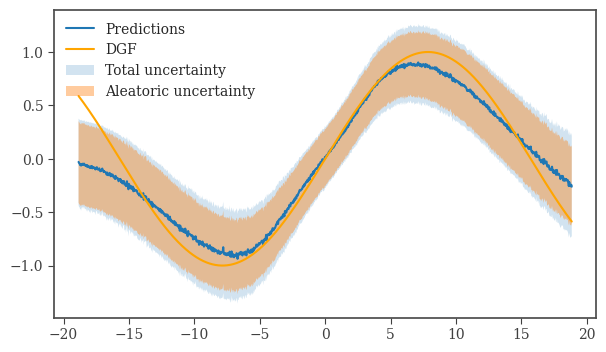

In [63]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4,
                label="Aleatoric uncertainty")

ax.legend()

plt.show()